# Analysis of results

### Setup

In [28]:
%reload_ext autoreload
%autoreload 2

In [29]:
# Setup working directory
from pathlib import Path
import os

def find_root_dir(marker='tfg'):
    p = Path.cwd()
    for candidate in [p] + list(p.parents):
        if candidate.name == marker:
            return candidate.resolve()
        if (candidate / marker).is_dir():
            return (candidate / marker).resolve()
    raise FileNotFoundError(f"Could not find '{marker}' folder in {Path.cwd()} or its parents.")

os.chdir(find_root_dir('tfg'))

In [30]:
# Libraries for data manipulation and visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set Searborn style (background color, grid, axes, etc.) 
sns.set_style("whitegrid")

# Default values and styling for all plots
plt.rcParams.update({
    "figure.autolayout": True,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": False
})

## Configuration
- DataFrame containing the results of **12 experiments** (3 models x 4 feature configurations)
- Expected columns: `Model`,`Feature Set`,`Features Count`,`Train Time`,`Train Accuracy`,`Train F1`,`BENIGN`, `DDoS`, `FP`, `FN`, `TP`, `TN`, `FP Rate`, `Accuracy`, `F1`

In [31]:
RESULTS = "results/results_stage_I.json"
df = pd.read_json(RESULTS, orient="split")

In [32]:
feature_order = [
    "numeric",
    "encoded",
    "correlation_08",
    "correlation_09"
]

df["Feature Set"] = pd.Categorical(
    df["Feature Set"],
    categories=feature_order,
    ordered=True
)

df = df.sort_values(
    ["Model", "Feature Set"]
).reset_index(drop=True)

display(df)

,Model,Feature Set,Features Count,Train Time,Train Accuracy,Train F1,BENIGN,DDoS,FP,FN,TP,TN,FP Rate,Accuracy,F1,Features Names
0,Logistic Regression,numeric,67,2.056,0.945599,0.945501,800,800,93,6,794,707,0.11625,0.938125,0.937942,"[Flow Duration, Total Fwd Packets, Total Backw..."
1,Logistic Regression,encoded,78,2.069,0.944505,0.944419,800,800,91,11,789,709,0.11375,0.936250,0.936090,"[Source IP, Destination IP, Flow Duration, Tot..."
2,Logistic Regression,correlation_08,35,2.155,0.987025,0.987025,800,800,7,14,786,793,0.00875,0.986875,0.986875,"[Source IP, Destination IP, Fwd Packet Length ..."
3,Logistic Regression,correlation_09,41,2.056,0.964671,0.964665,800,800,33,16,784,767,0.04125,0.969375,0.969372,"[Source IP, Destination IP, Fwd Packet Length ..."
4,MLP,numeric,67,0.850,0.987338,0.987337,800,800,18,5,795,782,0.02250,0.985625,0.985624,"[Flow Duration, Total Fwd Packets, Total Backw..."
5,MLP,encoded,78,0.651,0.980460,0.980455,800,800,26,6,794,774,0.03250,0.980000,0.979997,"[Source IP, Destination IP, Flow Duration, Tot..."
6,MLP,correlation_08,35,1.030,0.965922,0.965909,800,800,38,14,786,762,0.04750,0.967500,0.967493,"[Source IP, Destination IP, Fwd Packet Length ..."
7,MLP,correlation_09,41,0.646,0.819759,0.814262,800,800,3,280,520,797,0.00375,0.823125,0.817660,"[Source IP, Destination IP, Fwd Packet Length ..."
8,SVC,numeric,67,0.570,0.884946,0.884920,800,800,84,87,713,716,0.10500,0.893125,0.893125,"[Flow Duration, Total Fwd Packets, Total Backw..."
9,SVC,encoded,78,0.599,0.884946,0.884920,800,800,84,87,713,716,0.10500,0.893125,0.893125,"[Source IP, Destination IP, Flow Duration, Tot..."


## F1-Score Analysis
**Objective**: to have a overall overview and show which configurations stand out and which show degradation.

---

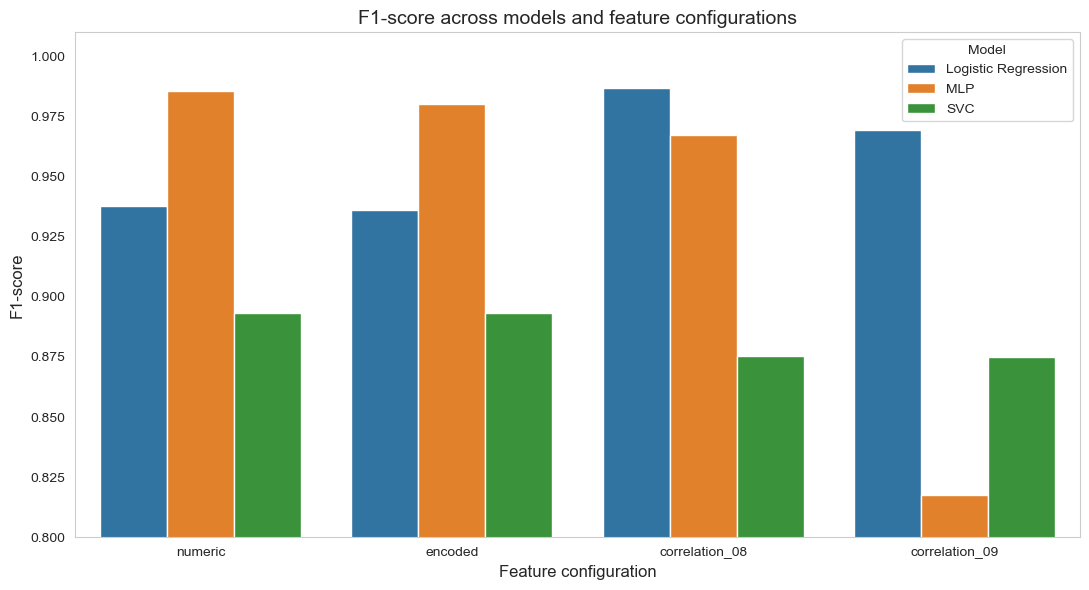

In [33]:
def plot_f1_results(results):
    plt.figure(figsize=(11, 6))
    sns.barplot(
        data=results,
        x="Feature Set",
        y="F1",
        hue="Model",
    )
    plt.xlabel("Feature configuration")
    plt.ylabel("F1-score")
    plt.title("F1-score across models and feature configurations")
    plt.ylim(0.80, 1.01)
    plt.legend(title="Model")
    plt.grid(False)
    plt.show()

plot_f1_results(df)

In [34]:
ranking = (
    df[
        [
            "Model",
            "Feature Set",
            "Features Count",
            "F1",
            "FP Rate"
        ]
    ]
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(ranking)

,Model,Feature Set,Features Count,F1,FP Rate
0,Logistic Regression,correlation_08,35,0.986875,0.00875
1,MLP,numeric,67,0.985624,0.02250
2,MLP,encoded,78,0.979997,0.03250
3,Logistic Regression,correlation_09,41,0.969372,0.04125
4,MLP,correlation_08,35,0.967493,0.04750
5,Logistic Regression,numeric,67,0.937942,0.11625
6,Logistic Regression,encoded,78,0.936090,0.11375
7,SVC,numeric,67,0.893125,0.10500
8,SVC,encoded,78,0.893125,0.10500
9,SVC,correlation_08,35,0.875488,0.09125


**Analysis**: all three models achieve relatively **strong performance** on the reference dataset, with F1-score ranging from 0.81 to 0.98. Logistic Regression achieves the best overall performance with the `correlation_08` feature set. Overall, the `encoded` configuration shows a slight advantage over the `numeric` configuration.

**Key Takeaways Stage II**: study the **effect** of categorical features, is it really worth it? study the effect of feature reduction, how correlation-based feature reduction affects each model?

---

## The Effect of Encoding Categorical Features
**Objective**: does the inclusion of categorical features provide meaningful improvements, or does it mainly increase dimensionality and model complexity?

---

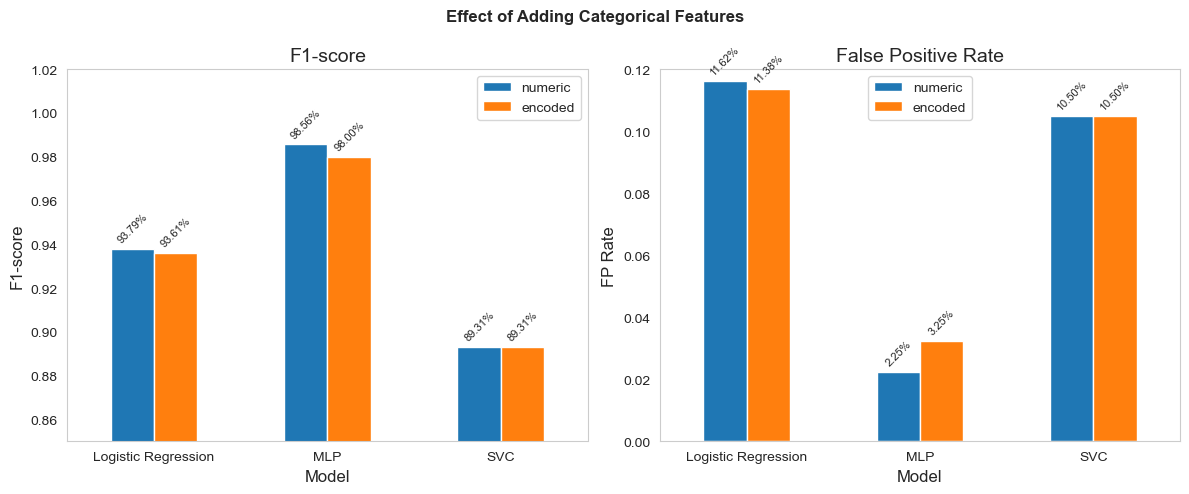

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
numeric_f1 = df[df["Feature Set"] == "numeric"].set_index("Model")["F1"]
encoded_f1 = df[df["Feature Set"] == "encoded"].set_index("Model")["F1"]
f1_data = pd.DataFrame({
    "numeric": numeric_f1,
    "encoded": encoded_f1
})

ax = f1_data.plot(kind="bar", ax=axes[0])
axes[0].set_title("F1-score")
axes[0].set_ylabel("F1-score")
axes[0].set_ylim(0.85, 1.02)
axes[0].tick_params(axis="x", rotation=0)
for container in ax.containers:
    labels = [
        f"{bar.get_height() * 100:.2f}%"
        for bar in container]
    ax.bar_label(container, labels=labels, padding=3, rotation=45, fontsize=8)

numeric_fp = df[df["Feature Set"] == "numeric"].set_index("Model")["FP Rate"]
encoded_fp = df[df["Feature Set"] == "encoded"].set_index("Model")["FP Rate"]
fp_data = pd.DataFrame({
    "numeric": numeric_fp,
    "encoded": encoded_fp
})

ax = fp_data.plot(kind="bar", ax=axes[1])
axes[1].set_title("False Positive Rate")
axes[1].set_ylabel("FP Rate")
axes[1].set_ylim(0, 0.12)
axes[1].tick_params(axis="x", rotation=0)
for container in ax.containers:
    labels = [
        f"{bar.get_height() * 100:.2f}%"
        for bar in container]
    ax.bar_label(container, labels=labels, padding=3, rotation=45, fontsize=8)

plt.suptitle("Effect of Adding Categorical Features", fontweight="bold")
plt.show()

In [39]:
ranking = (
    df.query("`Feature Set` == 'encoded'")[
        [
            "Model",
            "Feature Set",
            "F1",
            "FP Rate",
            "FP",
            "FN"
        ]
    ]
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(ranking)

,Model,Feature Set,F1,FP Rate,FP,FN
0,MLP,encoded,0.979997,0.03250,26,6
1,Logistic Regression,encoded,0.936090,0.11375,91,11
2,SVC,encoded,0.893125,0.10500,84,87


**Analysis**: the inclusion of categorical features provides only a marginal improvement in F1-score, while slightly reducing the FP Rate for MLP. Therefore, the contribution to the performance appears limited relative to the increase of dimensionality.

**Key Takeaways Stage II**:  these limited improvement raises the question of whether their contribution reflects intrinsic traffic characteristics or dataset-specific patterns.

---

## The Effect of Feature Reduccion
**Objective**: does more features mean better models?

---

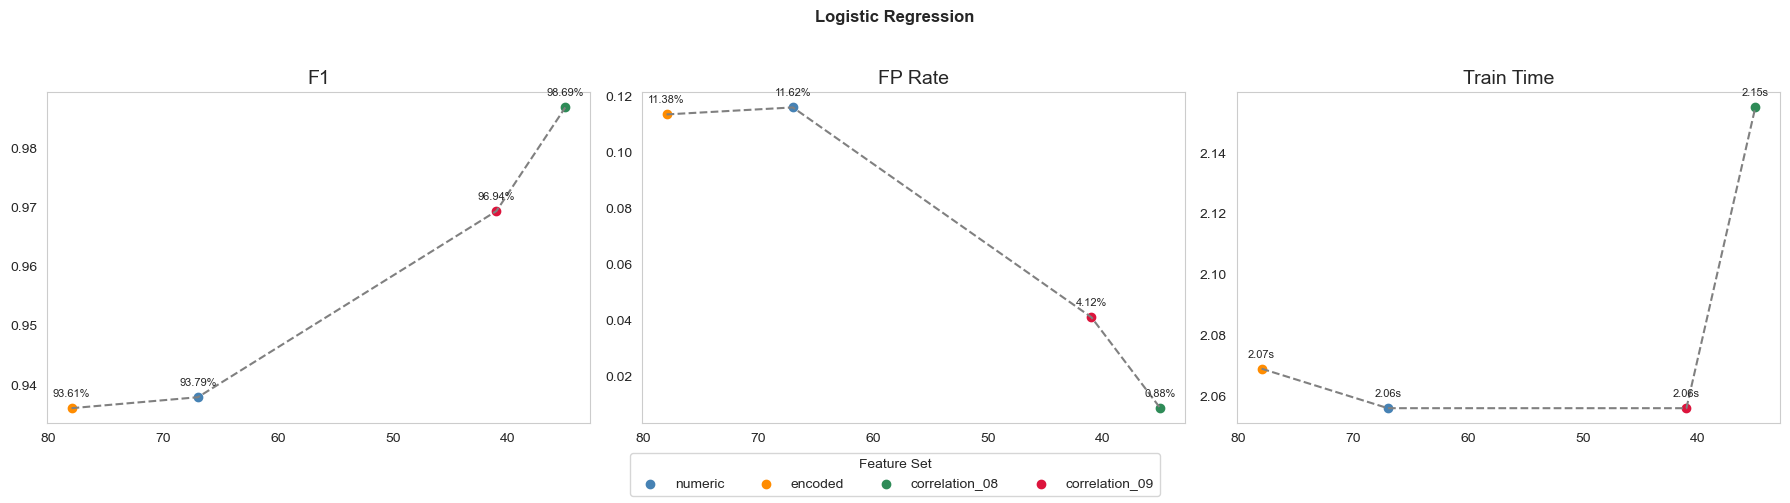

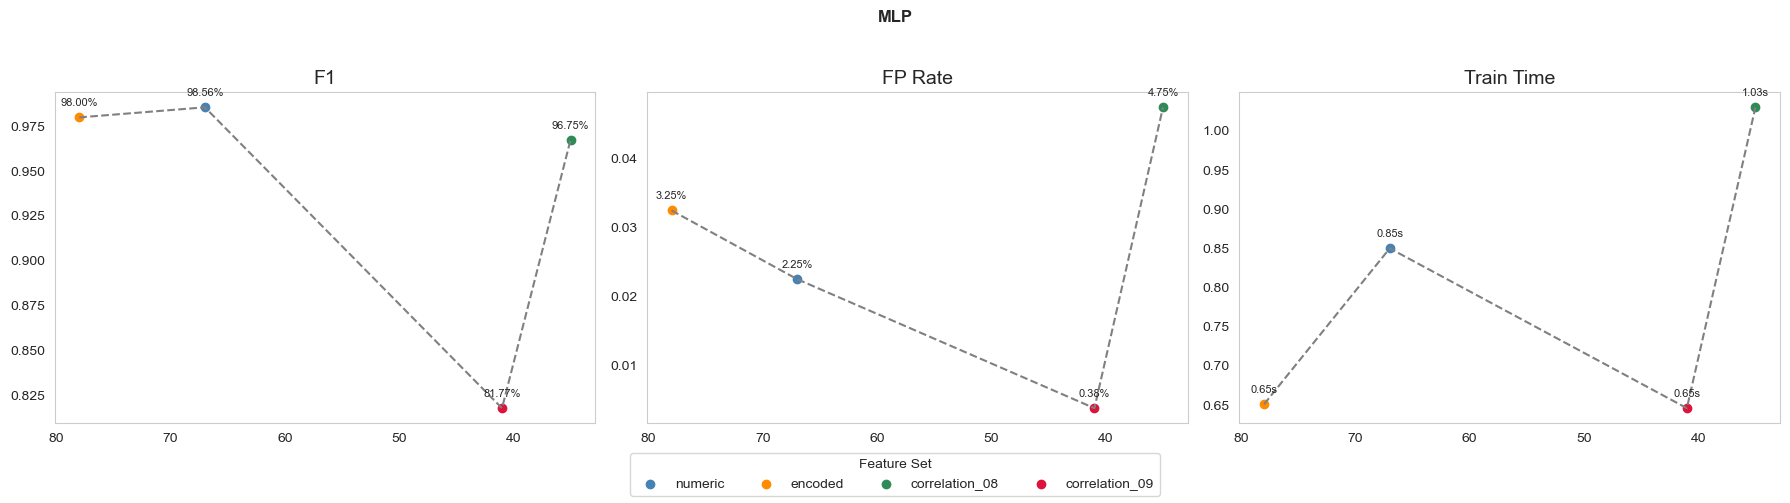

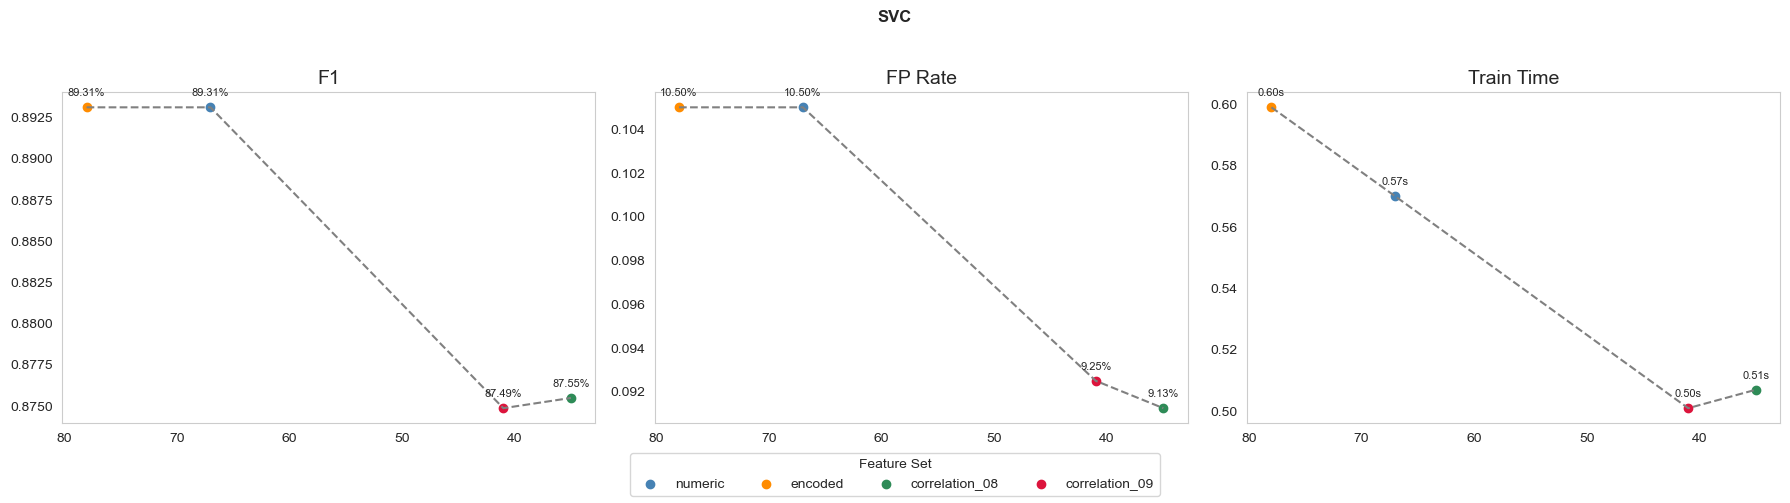

In [36]:
def plot_feature_reduction_effect(df):
    colors = {
        "numeric": "steelblue",
        "encoded": "darkorange",
        "correlation_08": "seagreen",
        "correlation_09": "crimson"
    }

    for model in df["Model"].unique():
        data = df[df["Model"] == model].sort_values(
            "Features Count",
            ascending=False)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for ax, metric in zip(axes, ["F1", "FP Rate", "Train Time"]):
            ax.plot(
                data["Features Count"],
                data[metric],
                linestyle="--", color="gray")

            for feature_set, color in colors.items():
                points = data[ data["Feature Set"] == feature_set]

                ax.scatter(
                    points["Features Count"],
                    points[metric],
                    color=color,
                    label=feature_set)

                for x, y in zip(points["Features Count"],points[metric]):
                    value = (
                        f"{y * 100:.2f}%"
                        if metric != "Train Time"
                        else f"{y:.2f}s")

                    ax.annotate(
                        value,
                        (x, y),
                        xytext=(0, 8),
                        textcoords="offset points",
                        ha="center",
                        fontsize=8)

            ax.set_title(metric)
            ax.grid(False)
            ax.invert_xaxis()

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            title="Feature Set",
            loc="lower center",
            ncol=4)
        fig.suptitle(model, fontweight="bold")
        plt.tight_layout(rect=[0, 0.08, 1, 0.95])
        plt.show()


plot_feature_reduction_effect(df)

**Analysis**:  
- Logistic Regression shows the most positive response to feature reduction. ``F1-score`` increases from 93% to 98%. At the same time, ``FP Rate`` and ``Train Time`` decreases from 11.38% to 0.88% and from 2.07s to 2.06s but auments on the last feature set to 2.15s. 
- The features removed appear to contain information that is useful for the MLP. ``F1-score`` decreases and ``FP Rate`` increases in the last feature set. ``Train Time`` does not have a clear tendency. 
- SVM shows a negative response to feature reduction. The main benefit for SVC model is therefore computational as ``Train Time`` decreases. 

**Key Takeaways Stage II**: reducing dimensionality does **not** necessaritly lead to better performance. Feature reduction should be applied in a more precised way in order to find meaningful traffic features while maintaining the high performance already achieved by the baseline models.

---

## Stage II Hints
- Does a more precise feature reduction lead to better model performance?
- The inclusion of **categorical** features mainly increase dimensionality and model complexity.
- Keep baseline models, as they represent different levels of model complexity.
- Interpret the results by adding **tree**-based models and analysing feature importance.
- Find the most balanced model between `Performance + Generalization + Efficiency + Interpretability`.